In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
from scipy.integrate import quad
import torch
from torch import nn
from datetime import datetime
from matplotlib.gridspec import GridSpec
from tensorboard.backend.event_processing import event_accumulator

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CallbackList, EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../")

In [3]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

### Parameters

In [4]:
max_inventory = 20

seed = 42

In [5]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [6]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi = compute_psi(fads_proportion)

print("psi value:", psi)

psi value: 14.872283180889763


In [7]:
def get_closed_form_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      normalise_rewards = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

#### Cartea Jaimungal Agent

In [8]:
cj_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [9]:
cj_agent = ModifiedCarteaJaimungalMmAgent(env=cj_env)
print(cj_env.model_dynamics
      .midprice_model)


In [10]:
num_trajectories = 1000
vec_cj_env = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_cj = ModifiedCarteaJaimungalMmAgent(env=vec_cj_env)

print(vec_cj_env.model_dynamics
      .midprice_model)

In [11]:
observations_cj, actions_cj, rewards_cj = generate_trajectory(vec_cj_env, vec_cj)

In [12]:
results_cj, fig_cj, total_rewards_cj = generate_results_table_and_hist(vec_env=vec_cj_env,agent=vec_cj)

In [13]:
results_cj

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065896,21.133681,4.809688,-0.071,3.106116


#### Full Information Agent

In [14]:
fi_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [15]:
fi_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=fi_env)
print(fi_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 1000 time points


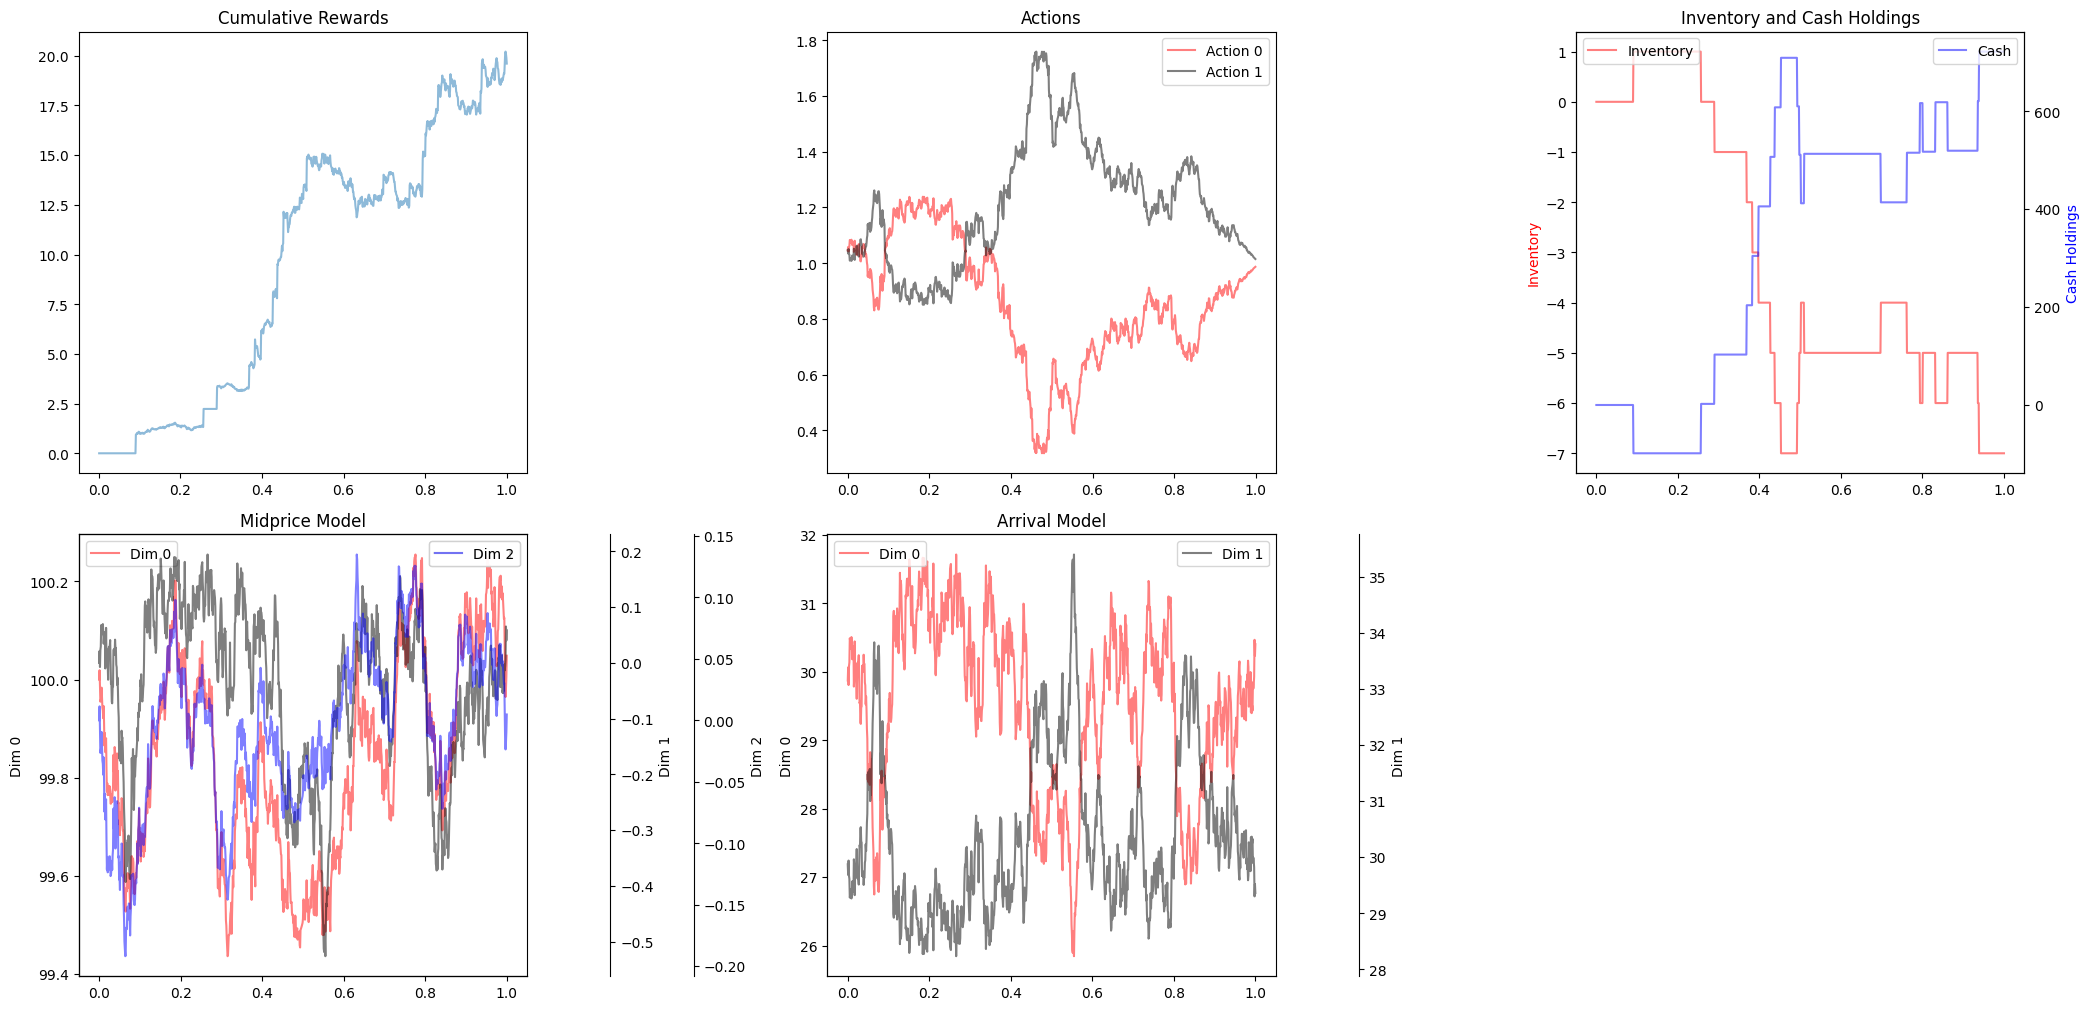

In [16]:
plot_trajectory_extended(fi_env, fi_agent)

In [17]:
num_trajectories = 1000
vec_env_fi = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_agent_fi = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env_fi)

print(vec_env_fi.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


In [18]:
observations_fi, actions_fi, rewards_fi = generate_trajectory(vec_env_fi, vec_agent_fi)

In [19]:
results_fi, fig_fi, total_rewards_fi = generate_results_table_and_hist(vec_env=vec_env_fi,agent=vec_agent_fi)

In [20]:
results_fi

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065432,21.259366,4.896308,-0.098,3.100386


#### Partial Information Agent

In [21]:
pi_env = get_closed_form_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [22]:
pi_agent = OptimizedPartialInfoMMwithFadsInformedUniformedTradersAgent(env=pi_env)
print(pi_env.model_dynamics
      .midprice_model)


✓ Pre-computed ODE solutions for 1000 time points


In [23]:
num_trajectories = 1000
vec_pi_env = get_closed_form_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_pi_agent = OptimizedPartialInfoMMwithFadsInformedUniformedTradersAgent(env=vec_pi_env)

print(vec_pi_env.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


In [24]:
observations_pi, actions_pi, rewards_pi = generate_trajectory(vec_pi_env, vec_pi_agent)

In [25]:
results_pi, fig_pi, total_rewards_pi = generate_results_table_and_hist(vec_env=vec_pi_env,agent=vec_pi_agent)

In [26]:
results_pi

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065432,21.145828,4.880012,-0.095,3.106441


## Random Inventory

### Plot for comparison

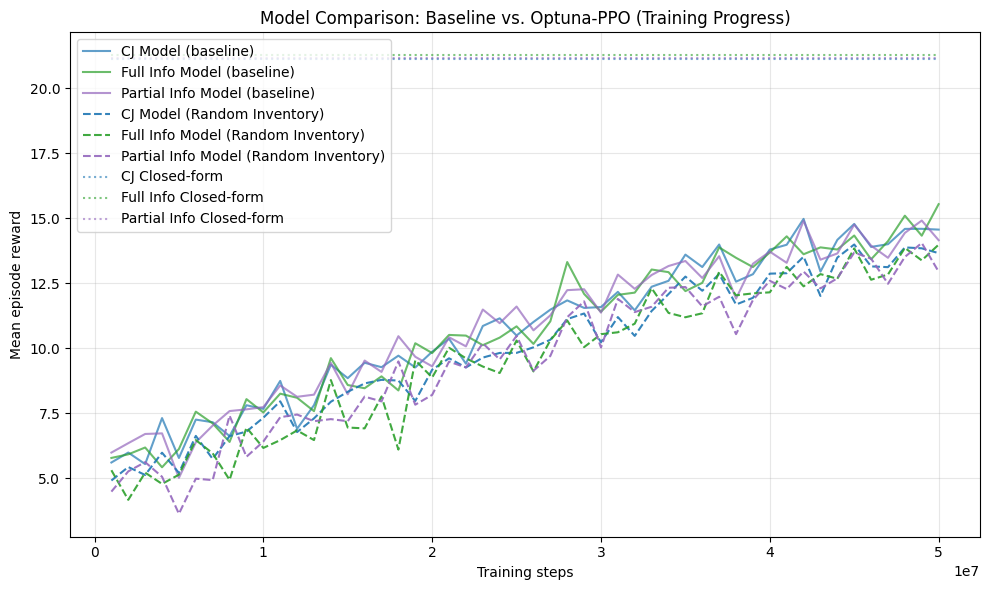

In [27]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# === Load rollout rewards for all six models ===

# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_randInventory_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_50_000_000steps_RandomInventory/2025-11-17_09-29-17/PPO_1/events.out.tfevents.1763368159.MacBookAir.lan.60781.0"
full_info_randInventory_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_randInventory/2025-11-17_09-46-13/PPO_1/events.out.tfevents.1763369175.MacBookAir.lan.63822.0"
partial_info_randInventory_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_randInventory/2025-11-17_10-13-52/PPO_1/events.out.tfevents.1763370833.MacBookAir.lan.69954.0"

# Helper to load rewards
def load_rollout(file_path, tag="rollout/ep_rew_mean"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    rewards = [e.value for e in events]
    return steps, rewards

# Load baseline
cj_steps, cj_rewards = load_rollout(cj_rollout_file)
full_steps, full_rewards = load_rollout(full_info_rollout_file)
partial_steps, partial_rewards = load_rollout(partial_info_rollout_file)

# Load random Inventory
cj_rand_steps, cj_rand_rewards = load_rollout(cj_randInventory_rollout_file)
full_rand_steps, full_rand_rewards = load_rollout(full_info_randInventory_rollout_file)
partial_rand_steps, partial_rand_rewards = load_rollout(partial_info_randInventory_rollout_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# Baseline models
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Model (baseline)', alpha=0.7)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Model (baseline)', alpha=0.7)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Model (baseline)', alpha=0.7)

# Optuna models
ax.plot(cj_rand_steps, cj_rand_rewards, '--', color='tab:blue', label='CJ Model (Random Inventory)', alpha=0.9)
ax.plot(full_rand_steps, full_rand_rewards, '--', color='tab:green', label='Full Info Model (Random Inventory)', alpha=0.9)
ax.plot(partial_rand_steps, partial_rand_rewards, '--', color='tab:purple', label='Partial Info Model (Random Inventory)', alpha=0.9)

# Add closed-form baselines
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.6)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.6)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.6)

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Baseline vs. Optuna-PPO (Training Progress)')
ax.legend()
plt.tight_layout()
plt.show()


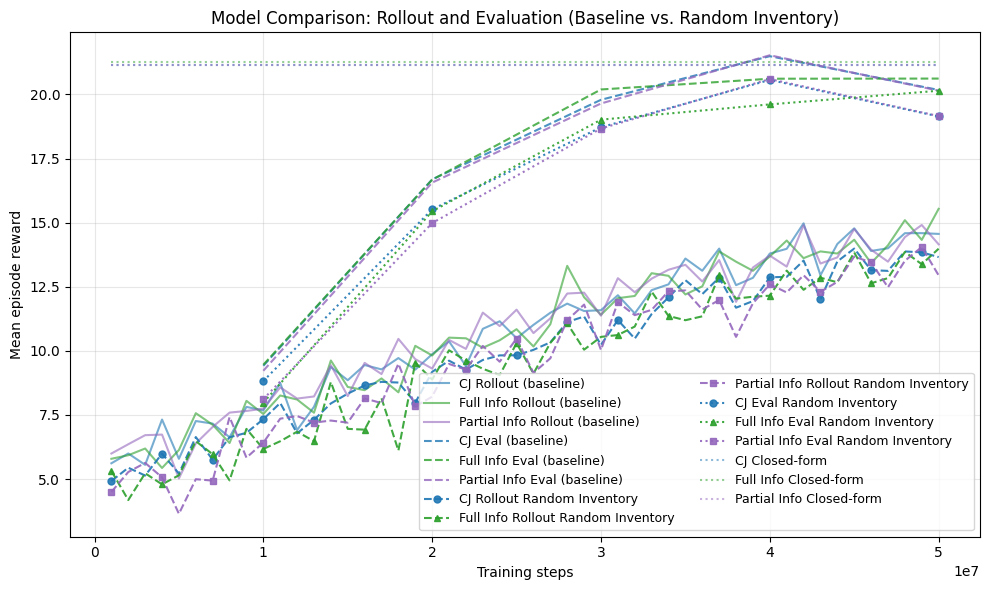

In [28]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# Define tensorboard files
# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_randInventory_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_50_000_000steps_RandomInventory/2025-11-17_09-29-17/PPO_1/events.out.tfevents.1763368159.MacBookAir.lan.60781.0"
full_info_randInventory_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_randInventory/2025-11-17_09-46-13/PPO_1/events.out.tfevents.1763369175.MacBookAir.lan.63822.0"
partial_info_randInventory_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_randInventory/2025-11-17_10-13-52/PPO_1/events.out.tfevents.1763370833.MacBookAir.lan.69954.0"

# === Helper to load data ===
def load_rewards(file_path, rollout_tag="rollout/ep_rew_mean", eval_tag="eval/mean_reward"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    tags = ea.Tags().get('scalars', [])

    rollout_events = ea.Scalars(rollout_tag)
    rollout_steps = [e.step for e in rollout_events]
    rollout_rewards = [e.value for e in rollout_events]

    eval_steps, eval_rewards = [], []
    if eval_tag in tags:
        eval_events = ea.Scalars(eval_tag)
        eval_steps = [e.step for e in eval_events]
        eval_rewards = [e.value for e in eval_events]

    return rollout_steps, rollout_rewards, eval_steps, eval_rewards

# === Load all baseline models ===
cj_steps, cj_rewards, cj_eval_steps, cj_eval_rewards = load_rewards(cj_rollout_file)
full_steps, full_rewards, full_eval_steps, full_eval_rewards = load_rewards(full_info_rollout_file)
partial_steps, partial_rewards, partial_eval_steps, partial_eval_rewards = load_rewards(partial_info_rollout_file)

# === Load all Optuna models ===
cj_rand_steps, cj_rand_rewards, cj_rand_eval_steps, cj_rand_eval_rewards = load_rewards(cj_randInventory_rollout_file)
full_rand_steps, full_rand_rewards, full_rand_eval_steps, full_rand_eval_rewards = load_rewards(full_info_randInventory_rollout_file)
partial_rand_steps, partial_rand_rewards, partial_rand_eval_steps, partial_rand_eval_rewards = load_rewards(partial_info_randInventory_rollout_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Rollout (baseline)', alpha=0.6)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Rollout (baseline)', alpha=0.6)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Rollout (baseline)', alpha=0.6)

if cj_eval_steps:
    ax.plot(cj_eval_steps, cj_eval_rewards, '--', color='tab:blue', alpha=0.8, label='CJ Eval (baseline)')
if full_eval_steps:
    ax.plot(full_eval_steps, full_eval_rewards, '--', color='tab:green', alpha=0.8, label='Full Info Eval (baseline)')
if partial_eval_steps:
    ax.plot(partial_eval_steps, partial_eval_rewards, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval (baseline)')

# ----- OPTUNA RUNS -----
ax.plot(cj_rand_steps, cj_rand_rewards, '--o', color='tab:blue', alpha=0.9,
        markersize=5, markevery=max(1, len(cj_rand_steps)//15), label='CJ Rollout Random Inventory')
ax.plot(full_rand_steps, full_rand_rewards, '--^', color='tab:green', alpha=0.9,
        markersize=5, markevery=max(1, len(full_rand_steps)//15), label='Full Info Rollout Random Inventory')
ax.plot(partial_rand_steps, partial_rand_rewards, '--s', color='tab:purple', alpha=0.9,
        markersize=5, markevery=max(1, len(partial_rand_steps)//15), label='Partial Info Rollout Random Inventory')

# Optuna eval (dotted with markers)
if cj_rand_eval_steps:
    ax.plot(cj_rand_eval_steps, cj_rand_eval_rewards, ':o', color='tab:blue', alpha=0.9,
            markersize=5, markevery=max(1, len(cj_rand_eval_steps)//15), label='CJ Eval Random Inventory')
if full_rand_eval_steps:
    ax.plot(full_rand_eval_steps, full_rand_eval_rewards, ':^', color='tab:green', alpha=0.9,
            markersize=5, markevery=max(1, len(full_rand_eval_steps)//15), label='Full Info Eval Random Inventory')
if partial_rand_eval_steps:
    ax.plot(partial_rand_eval_steps, partial_rand_eval_rewards, ':s', color='tab:purple', alpha=0.9,
            markersize=5, markevery=max(1, len(partial_rand_eval_steps)//15), label='Partial Info Eval Random Inventory')

# ----- CLOSED-FORM BASELINES -----
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Rollout and Evaluation (Baseline vs. Random Inventory)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()



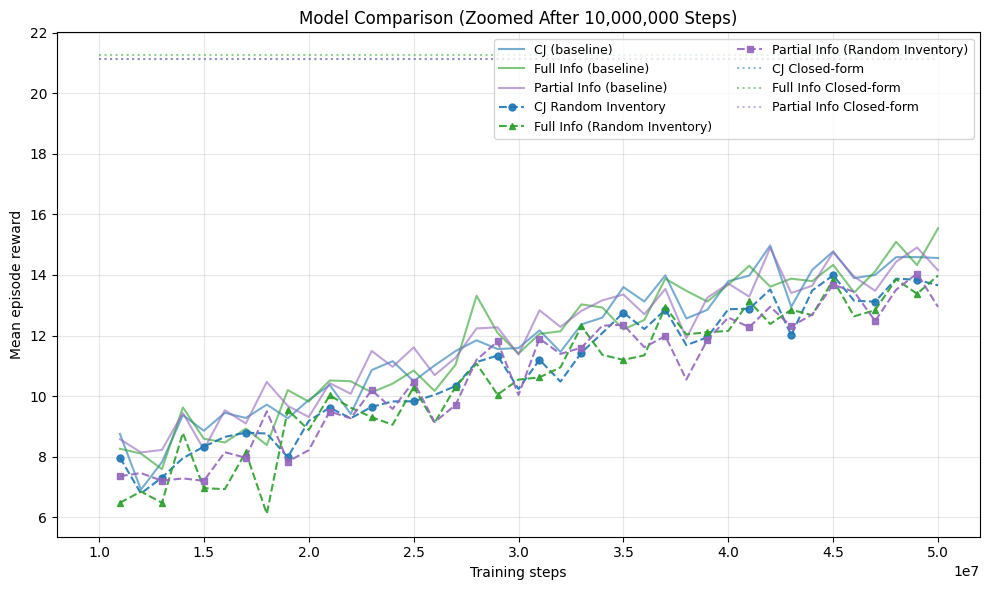

In [29]:
# === Zoomed-in plot after threshold ===

zoom_threshold = 10_000_000

# --- Filter data for steps > threshold ---
def zoom_filter(steps, rewards, threshold):
    return [s for s in steps if s > threshold], [r for s, r in zip(steps, rewards) if s > threshold]

cj_steps_zoom, cj_rewards_zoom = zoom_filter(cj_steps, cj_rewards, zoom_threshold)
full_steps_zoom, full_rewards_zoom = zoom_filter(full_steps, full_rewards, zoom_threshold)
partial_steps_zoom, partial_rewards_zoom = zoom_filter(partial_steps, partial_rewards, zoom_threshold)

cj_rand_steps_zoom, cj_rand_rewards_zoom = zoom_filter(cj_rand_steps, cj_rand_rewards, zoom_threshold)
full_rand_steps_zoom, full_rand_rewards_zoom = zoom_filter(full_rand_steps, full_rand_rewards, zoom_threshold)
partial_rand_steps_zoom, partial_rand_rewards_zoom = zoom_filter(partial_rand_steps, partial_rand_rewards, zoom_threshold)

# === Plot comparison (zoomed) ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps_zoom, cj_rewards_zoom, '-', color='tab:blue', label='CJ (baseline)', alpha=0.6)
ax.plot(full_steps_zoom, full_rewards_zoom, '-', color='tab:green', label='Full Info (baseline)', alpha=0.6)
ax.plot(partial_steps_zoom, partial_rewards_zoom, '-', color='tab:purple', label='Partial Info (baseline)', alpha=0.6)

# ----- OPTUNA RUNS -----
ax.plot(cj_rand_steps_zoom, cj_rand_rewards_zoom, '--o', color='tab:blue',
        alpha=0.9, markersize=5, markevery=max(1, len(cj_rand_steps_zoom)//15),
        label='CJ Random Inventory')
ax.plot(full_rand_steps_zoom, full_rand_rewards_zoom, '--^', color='tab:green',
        alpha=0.9, markersize=5, markevery=max(1, len(full_rand_steps_zoom)//15),
        label='Full Info (Random Inventory)')
ax.plot(partial_rand_steps_zoom, partial_rand_rewards_zoom, '--s', color='tab:purple',
        alpha=0.9, markersize=5, markevery=max(1, len(partial_rand_steps_zoom)//15),
        label='Partial Info (Random Inventory)')

# ----- CLOSED-FORM BASELINES -----
x_min = zoom_threshold
x_max = max(cj_steps + full_steps + partial_steps)

y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title(f'Model Comparison (Zoomed After {zoom_threshold:,} Steps)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


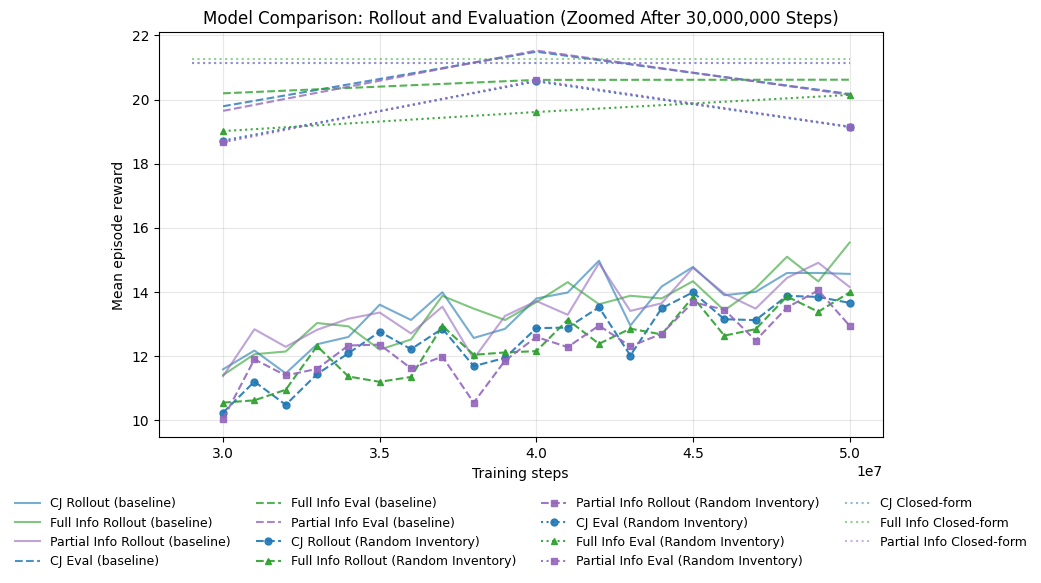

In [30]:
# === Zoomed-in plot after threshold (with evaluation) ===

zoom_threshold = 29_000_000

# --- Helper to filter steps/rewards ---
def zoom_filter(steps, rewards, threshold):
    return [s for s in steps if s > threshold], [r for s, r in zip(steps, rewards) if s > threshold]

# --- Baseline zoomed data ---
cj_steps_zoom, cj_rewards_zoom = zoom_filter(cj_steps, cj_rewards, zoom_threshold)
full_steps_zoom, full_rewards_zoom = zoom_filter(full_steps, full_rewards, zoom_threshold)
partial_steps_zoom, partial_rewards_zoom = zoom_filter(partial_steps, partial_rewards, zoom_threshold)

cj_eval_steps_zoom, cj_eval_rewards_zoom = zoom_filter(cj_eval_steps, cj_eval_rewards, zoom_threshold)
full_eval_steps_zoom, full_eval_rewards_zoom = zoom_filter(full_eval_steps, full_eval_rewards, zoom_threshold)
partial_eval_steps_zoom, partial_eval_rewards_zoom = zoom_filter(partial_eval_steps, partial_eval_rewards, zoom_threshold)

# --- Optuna zoomed data ---
cj_opt_steps_zoom, cj_opt_rewards_zoom = zoom_filter(cj_rand_steps, cj_rand_rewards, zoom_threshold)
full_opt_steps_zoom, full_opt_rewards_zoom = zoom_filter(full_rand_steps, full_rand_rewards, zoom_threshold)
partial_opt_steps_zoom, partial_opt_rewards_zoom = zoom_filter(partial_rand_steps, partial_rand_rewards, zoom_threshold)

cj_opt_eval_steps_zoom, cj_opt_eval_rewards_zoom = zoom_filter(cj_rand_eval_steps, cj_rand_eval_rewards, zoom_threshold)
full_opt_eval_steps_zoom, full_opt_eval_rewards_zoom = zoom_filter(full_rand_eval_steps, full_rand_eval_rewards, zoom_threshold)
partial_opt_eval_steps_zoom, partial_opt_eval_rewards_zoom = zoom_filter(partial_rand_eval_steps, partial_rand_eval_rewards, zoom_threshold)

# === Plot comparison (zoomed) ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps_zoom, cj_rewards_zoom, '-', color='tab:blue', label='CJ Rollout (baseline)', alpha=0.6)
ax.plot(full_steps_zoom, full_rewards_zoom, '-', color='tab:green', label='Full Info Rollout (baseline)', alpha=0.6)
ax.plot(partial_steps_zoom, partial_rewards_zoom, '-', color='tab:purple', label='Partial Info Rollout (baseline)', alpha=0.6)

# Baseline eval
if cj_eval_steps_zoom:
    ax.plot(cj_eval_steps_zoom, cj_eval_rewards_zoom, '--', color='tab:blue', alpha=0.8, label='CJ Eval (baseline)')
if full_eval_steps_zoom:
    ax.plot(full_eval_steps_zoom, full_eval_rewards_zoom, '--', color='tab:green', alpha=0.8, label='Full Info Eval (baseline)')
if partial_eval_steps_zoom:
    ax.plot(partial_eval_steps_zoom, partial_eval_rewards_zoom, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval (baseline)')

# ----- OPTUNA RUNS -----
ax.plot(cj_opt_steps_zoom, cj_opt_rewards_zoom, '--o', color='tab:blue', alpha=0.9,
        markersize=5, markevery=max(1, len(cj_opt_steps_zoom)//15), label='CJ Rollout (Random Inventory)')
ax.plot(full_opt_steps_zoom, full_opt_rewards_zoom, '--^', color='tab:green', alpha=0.9,
        markersize=5, markevery=max(1, len(full_opt_steps_zoom)//15), label='Full Info Rollout (Random Inventory)')
ax.plot(partial_opt_steps_zoom, partial_opt_rewards_zoom, '--s', color='tab:purple', alpha=0.9,
        markersize=5, markevery=max(1, len(partial_opt_steps_zoom)//15), label='Partial Info Rollout (Random Inventory)')
# Optuna eval (dotted lines with markers)
if cj_opt_eval_steps_zoom:
    ax.plot(cj_opt_eval_steps_zoom, cj_opt_eval_rewards_zoom, ':o', color='tab:blue', alpha=0.9,
            markersize=5, markevery=max(1, len(cj_opt_eval_steps_zoom)//15), label='CJ Eval (Random Inventory)')
if full_opt_eval_steps_zoom:
    ax.plot(full_opt_eval_steps_zoom, full_opt_eval_rewards_zoom, ':^', color='tab:green', alpha=0.9,
            markersize=5, markevery=max(1, len(full_opt_eval_steps_zoom)//15), label='Full Info Eval (Random Inventory)')
if partial_opt_eval_steps_zoom:
    ax.plot(partial_opt_eval_steps_zoom, partial_opt_eval_rewards_zoom, ':s', color='tab:purple', alpha=0.9,
            markersize=5, markevery=max(1, len(partial_opt_eval_steps_zoom)//15), label='Partial Info Eval (Random Inventory)')

# ----- CLOSED-FORM BASELINES -----
x_min = zoom_threshold
x_max = max(cj_steps + full_steps + partial_steps)

y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=x_min, xmax=x_max, linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=x_min, xmax=x_max, linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=x_min, xmax=x_max, linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title(f'Model Comparison: Rollout and Evaluation (Zoomed After 30,000,000 Steps)')
ax.legend(
    ncol=4,
    fontsize=9,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    frameon=False
)
plt.tight_layout()
plt.show()

## Random Initial Start

### Plot for comparison

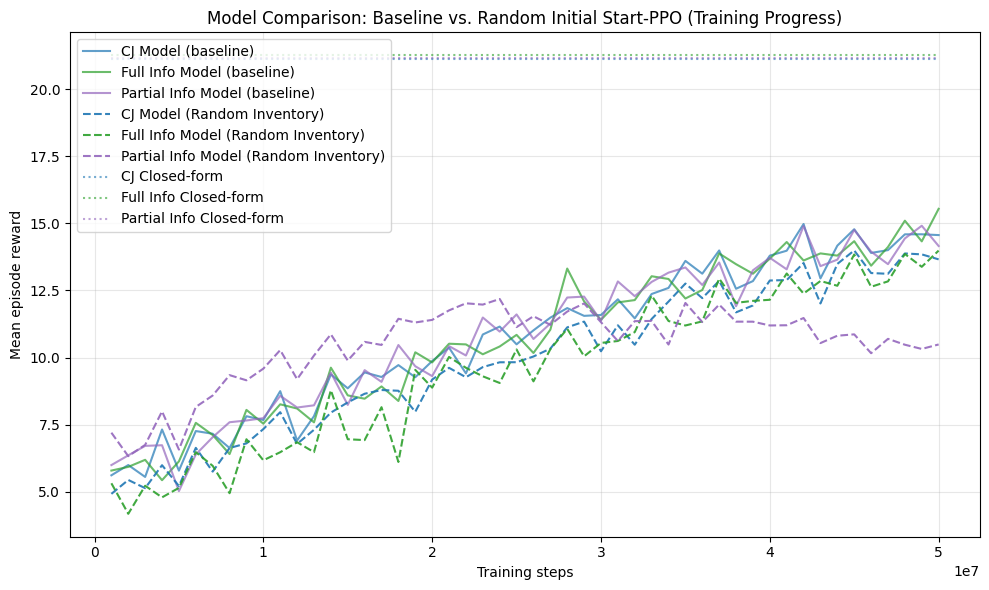

In [31]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# === Load rollout rewards for all six models ===

# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_randStart_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_50_000_000steps_RandomInventory/2025-11-17_09-29-17/PPO_1/events.out.tfevents.1763368159.MacBookAir.lan.60781.0"
full_info_randStart_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_randInventory/2025-11-17_09-46-13/PPO_1/events.out.tfevents.1763369175.MacBookAir.lan.63822.0"
partial_info_randStart_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PI_PPO_Optuna_Best/2025-11-04_10-08-50/PPO_1/events.out.tfevents.1762247330.MacBookAir.lan.67078.0"

# Helper to load rewards
def load_rollout(file_path, tag="rollout/ep_rew_mean"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    rewards = [e.value for e in events]
    return steps, rewards

# Load baseline
cj_steps, cj_rewards = load_rollout(cj_rollout_file)
full_steps, full_rewards = load_rollout(full_info_rollout_file)
partial_steps, partial_rewards = load_rollout(partial_info_rollout_file)

# Load random Inventory
cj_rand_steps, cj_rand_rewards = load_rollout(cj_randStart_rollout_file)
full_rand_steps, full_rand_rewards = load_rollout(full_info_randStart_rollout_file)
partial_rand_steps, partial_rand_rewards = load_rollout(partial_info_randStart_rollout_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# Baseline models
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Model (baseline)', alpha=0.7)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Model (baseline)', alpha=0.7)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Model (baseline)', alpha=0.7)

# Optuna models
ax.plot(cj_rand_steps, cj_rand_rewards, '--', color='tab:blue', label='CJ Model (Random Inventory)', alpha=0.9)
ax.plot(full_rand_steps, full_rand_rewards, '--', color='tab:green', label='Full Info Model (Random Inventory)', alpha=0.9)
ax.plot(partial_rand_steps, partial_rand_rewards, '--', color='tab:purple', label='Partial Info Model (Random Inventory)', alpha=0.9)

# Add closed-form baselines
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.6)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.6)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.6)

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Baseline vs. Random Initial Start-PPO (Training Progress)')
ax.legend()
plt.tight_layout()
plt.show()


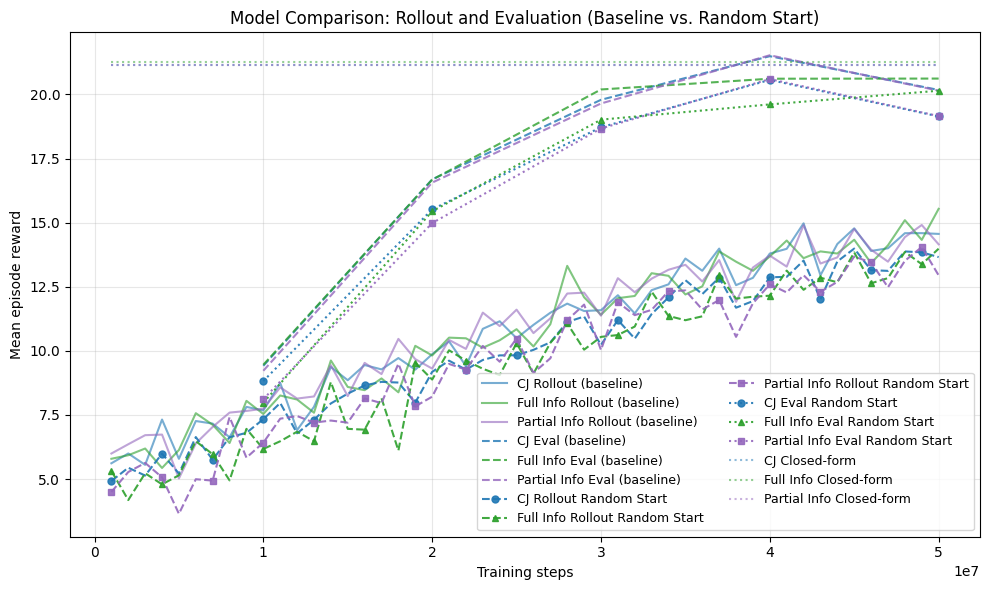

In [32]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# Define tensorboard files
# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_randStart_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_PPO_50_000_000steps_RandomInventory/2025-11-17_09-29-17/PPO_1/events.out.tfevents.1763368159.MacBookAir.lan.60781.0"
full_info_randStart_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_randInventory/2025-11-17_09-46-13/PPO_1/events.out.tfevents.1763369175.MacBookAir.lan.63822.0"
partial_info_randStart_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PI_PPO_Optuna_Best/2025-11-04_10-08-50/PPO_1/events.out.tfevents.1762247330.MacBookAir.lan.67078.0"

# === Helper to load data ===
def load_rewards(file_path, rollout_tag="rollout/ep_rew_mean", eval_tag="eval/mean_reward"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    tags = ea.Tags().get('scalars', [])

    rollout_events = ea.Scalars(rollout_tag)
    rollout_steps = [e.step for e in rollout_events]
    rollout_rewards = [e.value for e in rollout_events]

    eval_steps, eval_rewards = [], []
    if eval_tag in tags:
        eval_events = ea.Scalars(eval_tag)
        eval_steps = [e.step for e in eval_events]
        eval_rewards = [e.value for e in eval_events]

    return rollout_steps, rollout_rewards, eval_steps, eval_rewards

# === Load all baseline models ===
cj_steps, cj_rewards, cj_eval_steps, cj_eval_rewards = load_rewards(cj_rollout_file)
full_steps, full_rewards, full_eval_steps, full_eval_rewards = load_rewards(full_info_rollout_file)
partial_steps, partial_rewards, partial_eval_steps, partial_eval_rewards = load_rewards(partial_info_rollout_file)

# === Load all Optuna models ===
cj_rand_steps, cj_rand_rewards, cj_rand_eval_steps, cj_rand_eval_rewards = load_rewards(cj_randInventory_rollout_file)
full_rand_steps, full_rand_rewards, full_rand_eval_steps, full_rand_eval_rewards = load_rewards(full_info_randInventory_rollout_file)
partial_rand_steps, partial_rand_rewards, partial_rand_eval_steps, partial_rand_eval_rewards = load_rewards(partial_info_randInventory_rollout_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Rollout (baseline)', alpha=0.6)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Rollout (baseline)', alpha=0.6)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Rollout (baseline)', alpha=0.6)

if cj_eval_steps:
    ax.plot(cj_eval_steps, cj_eval_rewards, '--', color='tab:blue', alpha=0.8, label='CJ Eval (baseline)')
if full_eval_steps:
    ax.plot(full_eval_steps, full_eval_rewards, '--', color='tab:green', alpha=0.8, label='Full Info Eval (baseline)')
if partial_eval_steps:
    ax.plot(partial_eval_steps, partial_eval_rewards, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval (baseline)')

# ----- OPTUNA RUNS -----
ax.plot(cj_rand_steps, cj_rand_rewards, '--o', color='tab:blue', alpha=0.9,
        markersize=5, markevery=max(1, len(cj_rand_steps)//15), label='CJ Rollout Random Start')
ax.plot(full_rand_steps, full_rand_rewards, '--^', color='tab:green', alpha=0.9,
        markersize=5, markevery=max(1, len(full_rand_steps)//15), label='Full Info Rollout Random Start')
ax.plot(partial_rand_steps, partial_rand_rewards, '--s', color='tab:purple', alpha=0.9,
        markersize=5, markevery=max(1, len(partial_rand_steps)//15), label='Partial Info Rollout Random Start')
# Optuna eval (dotted with markers)
if cj_rand_eval_steps:
    ax.plot(cj_rand_eval_steps, cj_rand_eval_rewards, ':o', color='tab:blue', alpha=0.9,
            markersize=5, markevery=max(1, len(cj_rand_eval_steps)//15), label='CJ Eval Random Start')
if full_rand_eval_steps:
    ax.plot(full_rand_eval_steps, full_rand_eval_rewards, ':^', color='tab:green', alpha=0.9,
            markersize=5, markevery=max(1, len(full_rand_eval_steps)//15), label='Full Info Eval Random Start')
if partial_rand_eval_steps:
    ax.plot(partial_rand_eval_steps, partial_rand_eval_rewards, ':s', color='tab:purple', alpha=0.9,
            markersize=5, markevery=max(1, len(partial_rand_eval_steps)//15), label='Partial Info Eval Random Start')

# ----- CLOSED-FORM BASELINES -----
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Rollout and Evaluation (Baseline vs. Random Start)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()



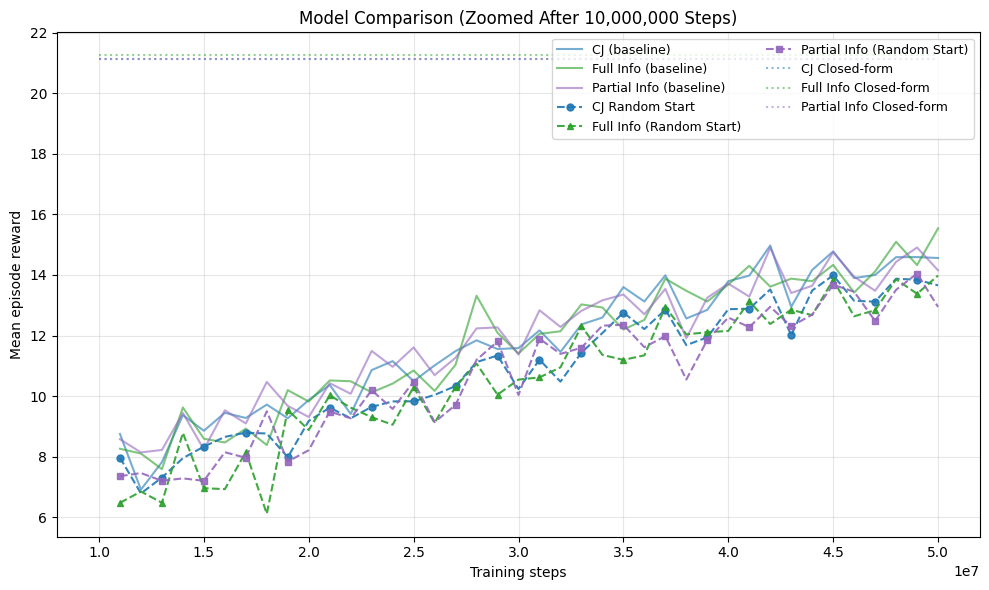

In [33]:
# === Zoomed-in plot after threshold ===

zoom_threshold = 10_000_000

# --- Filter data for steps > threshold ---
def zoom_filter(steps, rewards, threshold):
    return [s for s in steps if s > threshold], [r for s, r in zip(steps, rewards) if s > threshold]

cj_steps_zoom, cj_rewards_zoom = zoom_filter(cj_steps, cj_rewards, zoom_threshold)
full_steps_zoom, full_rewards_zoom = zoom_filter(full_steps, full_rewards, zoom_threshold)
partial_steps_zoom, partial_rewards_zoom = zoom_filter(partial_steps, partial_rewards, zoom_threshold)

cj_rand_steps_zoom, cj_rand_rewards_zoom = zoom_filter(cj_rand_steps, cj_rand_rewards, zoom_threshold)
full_rand_steps_zoom, full_rand_rewards_zoom = zoom_filter(full_rand_steps, full_rand_rewards, zoom_threshold)
partial_rand_steps_zoom, partial_rand_rewards_zoom = zoom_filter(partial_rand_steps, partial_rand_rewards, zoom_threshold)

# === Plot comparison (zoomed) ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps_zoom, cj_rewards_zoom, '-', color='tab:blue', label='CJ (baseline)', alpha=0.6)
ax.plot(full_steps_zoom, full_rewards_zoom, '-', color='tab:green', label='Full Info (baseline)', alpha=0.6)
ax.plot(partial_steps_zoom, partial_rewards_zoom, '-', color='tab:purple', label='Partial Info (baseline)', alpha=0.6)

# ----- OPTUNA RUNS -----
ax.plot(cj_rand_steps_zoom, cj_rand_rewards_zoom, '--o', color='tab:blue',
        alpha=0.9, markersize=5, markevery=max(1, len(cj_rand_steps_zoom)//15),
        label='CJ Random Start')
ax.plot(full_rand_steps_zoom, full_rand_rewards_zoom, '--^', color='tab:green',
        alpha=0.9, markersize=5, markevery=max(1, len(full_rand_steps_zoom)//15),
        label='Full Info (Random Start)')
ax.plot(partial_rand_steps_zoom, partial_rand_rewards_zoom, '--s', color='tab:purple',
        alpha=0.9, markersize=5, markevery=max(1, len(partial_rand_steps_zoom)//15),
        label='Partial Info (Random Start)')

# ----- CLOSED-FORM BASELINES -----
x_min = zoom_threshold
x_max = max(cj_steps + full_steps + partial_steps)

y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title(f'Model Comparison (Zoomed After {zoom_threshold:,} Steps)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


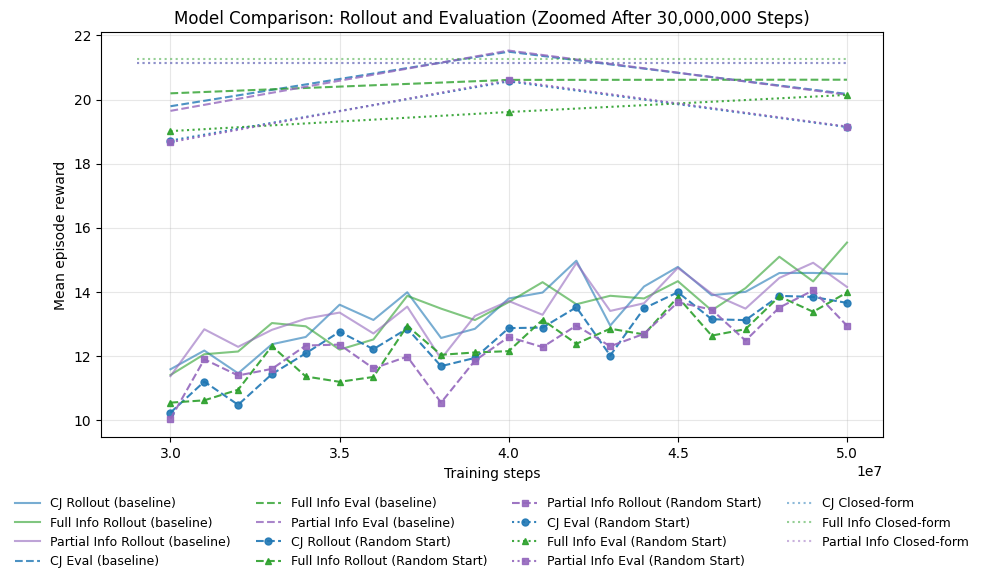

In [34]:
# === Zoomed-in plot after threshold (with evaluation) ===

zoom_threshold = 29_000_000

# --- Helper to filter steps/rewards ---
def zoom_filter(steps, rewards, threshold):
    return [s for s in steps if s > threshold], [r for s, r in zip(steps, rewards) if s > threshold]

# --- Baseline zoomed data ---
cj_steps_zoom, cj_rewards_zoom = zoom_filter(cj_steps, cj_rewards, zoom_threshold)
full_steps_zoom, full_rewards_zoom = zoom_filter(full_steps, full_rewards, zoom_threshold)
partial_steps_zoom, partial_rewards_zoom = zoom_filter(partial_steps, partial_rewards, zoom_threshold)

cj_eval_steps_zoom, cj_eval_rewards_zoom = zoom_filter(cj_eval_steps, cj_eval_rewards, zoom_threshold)
full_eval_steps_zoom, full_eval_rewards_zoom = zoom_filter(full_eval_steps, full_eval_rewards, zoom_threshold)
partial_eval_steps_zoom, partial_eval_rewards_zoom = zoom_filter(partial_eval_steps, partial_eval_rewards, zoom_threshold)

# --- Optuna zoomed data ---
cj_opt_steps_zoom, cj_opt_rewards_zoom = zoom_filter(cj_rand_steps, cj_rand_rewards, zoom_threshold)
full_opt_steps_zoom, full_opt_rewards_zoom = zoom_filter(full_rand_steps, full_rand_rewards, zoom_threshold)
partial_opt_steps_zoom, partial_opt_rewards_zoom = zoom_filter(partial_rand_steps, partial_rand_rewards, zoom_threshold)

cj_opt_eval_steps_zoom, cj_opt_eval_rewards_zoom = zoom_filter(cj_rand_eval_steps, cj_rand_eval_rewards, zoom_threshold)
full_opt_eval_steps_zoom, full_opt_eval_rewards_zoom = zoom_filter(full_rand_eval_steps, full_rand_eval_rewards, zoom_threshold)
partial_opt_eval_steps_zoom, partial_opt_eval_rewards_zoom = zoom_filter(partial_rand_eval_steps, partial_rand_eval_rewards, zoom_threshold)

# === Plot comparison (zoomed) ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps_zoom, cj_rewards_zoom, '-', color='tab:blue', label='CJ Rollout (baseline)', alpha=0.6)
ax.plot(full_steps_zoom, full_rewards_zoom, '-', color='tab:green', label='Full Info Rollout (baseline)', alpha=0.6)
ax.plot(partial_steps_zoom, partial_rewards_zoom, '-', color='tab:purple', label='Partial Info Rollout (baseline)', alpha=0.6)

# Baseline eval
if cj_eval_steps_zoom:
    ax.plot(cj_eval_steps_zoom, cj_eval_rewards_zoom, '--', color='tab:blue', alpha=0.8, label='CJ Eval (baseline)')
if full_eval_steps_zoom:
    ax.plot(full_eval_steps_zoom, full_eval_rewards_zoom, '--', color='tab:green', alpha=0.8, label='Full Info Eval (baseline)')
if partial_eval_steps_zoom:
    ax.plot(partial_eval_steps_zoom, partial_eval_rewards_zoom, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval (baseline)')

# ----- OPTUNA RUNS -----
ax.plot(cj_opt_steps_zoom, cj_opt_rewards_zoom, '--o', color='tab:blue', alpha=0.9,
        markersize=5, markevery=max(1, len(cj_opt_steps_zoom)//15), label='CJ Rollout (Random Start)')
ax.plot(full_opt_steps_zoom, full_opt_rewards_zoom, '--^', color='tab:green', alpha=0.9,
        markersize=5, markevery=max(1, len(full_opt_steps_zoom)//15), label='Full Info Rollout (Random Start)')
ax.plot(partial_opt_steps_zoom, partial_opt_rewards_zoom, '--s', color='tab:purple', alpha=0.9,
        markersize=5, markevery=max(1, len(partial_opt_steps_zoom)//15), label='Partial Info Rollout (Random Start)')
# Optuna eval (dotted lines with markers)
if cj_opt_eval_steps_zoom:
    ax.plot(cj_opt_eval_steps_zoom, cj_opt_eval_rewards_zoom, ':o', color='tab:blue', alpha=0.9,
            markersize=5, markevery=max(1, len(cj_opt_eval_steps_zoom)//15), label='CJ Eval (Random Start)')
if full_opt_eval_steps_zoom:
    ax.plot(full_opt_eval_steps_zoom, full_opt_eval_rewards_zoom, ':^', color='tab:green', alpha=0.9,
            markersize=5, markevery=max(1, len(full_opt_eval_steps_zoom)//15), label='Full Info Eval (Random Start)')
if partial_opt_eval_steps_zoom:
    ax.plot(partial_opt_eval_steps_zoom, partial_opt_eval_rewards_zoom, ':s', color='tab:purple', alpha=0.9,
            markersize=5, markevery=max(1, len(partial_opt_eval_steps_zoom)//15), label='Partial Info Eval (Random Start)')

# ----- CLOSED-FORM BASELINES -----
x_min = zoom_threshold
x_max = max(cj_steps + full_steps + partial_steps)

y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=x_min, xmax=x_max, linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=x_min, xmax=x_max, linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=x_min, xmax=x_max, linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title(f'Model Comparison: Rollout and Evaluation (Zoomed After 30,000,000 Steps)')
ax.legend(
    ncol=4,
    fontsize=9,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    frameon=False
)
plt.tight_layout()
plt.show()

## Fixed Entropy regularization

### Plot for comparison

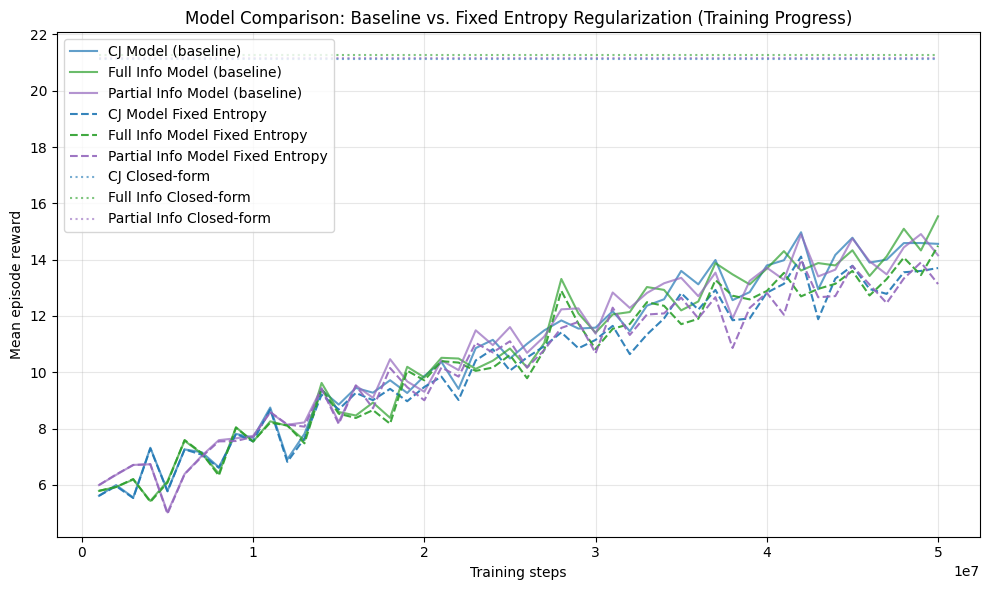

In [35]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# === Load rollout rewards for all six models ===

# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_Entropy_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps_Entropy/2025-11-17_10-46-28/PPO_1/events.out.tfevents.1763372790.MacBookAir.lan.75941.0"
full_info_Entropy_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline_Entropy/2025-11-18_09-03-39/PPO_1/events.out.tfevents.1763453021.MacBookAir.lan.20161.0"
partial_info_Entropy_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_Entropy/2025-11-17_10-31-37/PPO_1/events.out.tfevents.1763371898.MacBookAir.lan.72963.0"

# Load the data
# Helper to load rewards
def load_rollout(file_path, tag="rollout/ep_rew_mean"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    rewards = [e.value for e in events]
    return steps, rewards

# Load baseline
cj_steps, cj_rewards = load_rollout(cj_rollout_file)
full_steps, full_rewards = load_rollout(full_info_rollout_file)
partial_steps, partial_rewards = load_rollout(partial_info_rollout_file)

# Load random Inventory
cj_Entropy_steps, cj_Entropy_rewards = load_rollout(cj_Entropy_rollout_file)
full_Entropy_steps, full_Entropy_rewards = load_rollout(full_info_Entropy_rollout_file)
partial_Entropy_steps, partial_Entropy_rewards = load_rollout(partial_info_Entropy_rollout_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# Baseline models
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Model (baseline)', alpha=0.7)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Model (baseline)', alpha=0.7)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Model (baseline)', alpha=0.7)

# Optuna models
ax.plot(cj_Entropy_steps, cj_Entropy_rewards, '--', color='tab:blue', label='CJ Model Fixed Entropy', alpha=0.9)
ax.plot(full_Entropy_steps, full_Entropy_rewards, '--', color='tab:green', label='Full Info Model Fixed Entropy', alpha=0.9)
ax.plot(partial_Entropy_steps, partial_Entropy_rewards, '--', color='tab:purple', label='Partial Info Model Fixed Entropy', alpha=0.9)

# Add closed-form baselines
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.6)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.6)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.6)

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Baseline vs. Fixed Entropy Regularization (Training Progress)')
ax.legend()
plt.tight_layout()
plt.show()


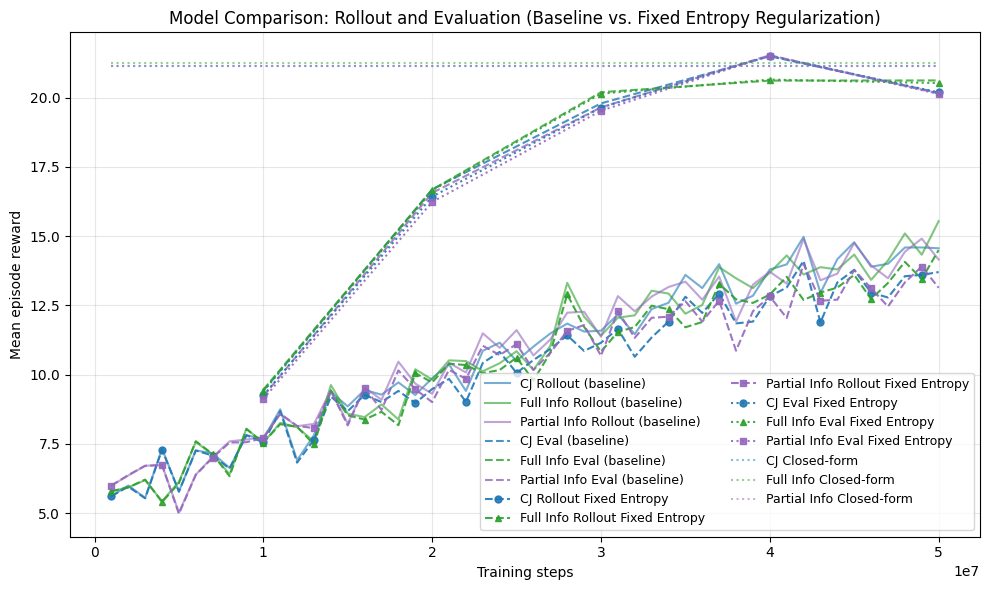

In [36]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# Define tensorboard files
# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_Entropy_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps_Entropy/2025-11-17_10-46-28/PPO_1/events.out.tfevents.1763372790.MacBookAir.lan.75941.0"
full_info_Entropy_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline_Entropy/2025-11-18_09-03-39/PPO_1/events.out.tfevents.1763453021.MacBookAir.lan.20161.0"
partial_info_Entropy_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_Entropy/2025-11-17_10-31-37/PPO_1/events.out.tfevents.1763371898.MacBookAir.lan.72963.0"

# === Helper to load data ===
def load_rewards(file_path, rollout_tag="rollout/ep_rew_mean", eval_tag="eval/mean_reward"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    tags = ea.Tags().get('scalars', [])

    rollout_events = ea.Scalars(rollout_tag)
    rollout_steps = [e.step for e in rollout_events]
    rollout_rewards = [e.value for e in rollout_events]

    eval_steps, eval_rewards = [], []
    if eval_tag in tags:
        eval_events = ea.Scalars(eval_tag)
        eval_steps = [e.step for e in eval_events]
        eval_rewards = [e.value for e in eval_events]

    return rollout_steps, rollout_rewards, eval_steps, eval_rewards

# === Load all baseline models ===
cj_steps, cj_rewards, cj_eval_steps, cj_eval_rewards = load_rewards(cj_rollout_file)
full_steps, full_rewards, full_eval_steps, full_eval_rewards = load_rewards(full_info_rollout_file)
partial_steps, partial_rewards, partial_eval_steps, partial_eval_rewards = load_rewards(partial_info_rollout_file)

# === Load all Optuna models ===
cj_Entropy_steps, cj_Entropy_rewards, cj_Entropy_eval_steps, cj_Entropy_eval_rewards = load_rewards(cj_Entropy_rollout_file)
full_Entropy_steps, full_Entropy_rewards, full_Entropy_eval_steps, full_Entropy_eval_rewards = load_rewards(full_info_Entropy_rollout_file)
partial_Entropy_steps, partial_Entropy_rewards, partial_Entropy_eval_steps, partial_Entropy_eval_rewards = load_rewards(partial_info_Entropy_rollout_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Rollout (baseline)', alpha=0.6)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Rollout (baseline)', alpha=0.6)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Rollout (baseline)', alpha=0.6)

if cj_eval_steps:
    ax.plot(cj_eval_steps, cj_eval_rewards, '--', color='tab:blue', alpha=0.8, label='CJ Eval (baseline)')
if full_eval_steps:
    ax.plot(full_eval_steps, full_eval_rewards, '--', color='tab:green', alpha=0.8, label='Full Info Eval (baseline)')
if partial_eval_steps:
    ax.plot(partial_eval_steps, partial_eval_rewards, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval (baseline)')


ax.plot(cj_Entropy_steps, cj_Entropy_rewards, '--o', color='tab:blue', alpha=0.9,
        markersize=5, markevery=max(1, len(cj_Entropy_steps)//15), label='CJ Rollout Fixed Entropy')
ax.plot(full_Entropy_steps, full_Entropy_rewards, '--^', color='tab:green', alpha=0.9,
        markersize=5, markevery=max(1, len(full_Entropy_steps)//15), label='Full Info Rollout Fixed Entropy')
ax.plot(partial_Entropy_steps, partial_Entropy_rewards, '--s', color='tab:purple', alpha=0.9,
        markersize=5, markevery=max(1, len(partial_Entropy_steps)//15), label='Partial Info Rollout Fixed Entropy')
# Optuna eval (dotted with markers)
if cj_Entropy_eval_steps:
    ax.plot(cj_Entropy_eval_steps, cj_Entropy_eval_rewards, ':o', color='tab:blue', alpha=0.9,
            markersize=5, markevery=max(1, len(cj_Entropy_eval_steps)//15), label='CJ Eval Fixed Entropy')
if full_Entropy_eval_steps:
    ax.plot(full_Entropy_eval_steps, full_Entropy_eval_rewards, ':^', color='tab:green', alpha=0.9,
            markersize=5, markevery=max(1, len(full_Entropy_eval_steps)//15), label='Full Info Eval Fixed Entropy')
if partial_Entropy_eval_steps:
    ax.plot(partial_Entropy_eval_steps, partial_Entropy_eval_rewards, ':s', color='tab:purple', alpha=0.9,
            markersize=5, markevery=max(1, len(partial_Entropy_eval_steps)//15), label='Partial Info Eval Fixed Entropy')

# ----- CLOSED-FORM BASELINES -----
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Rollout and Evaluation (Baseline vs. Fixed Entropy Regularization)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()



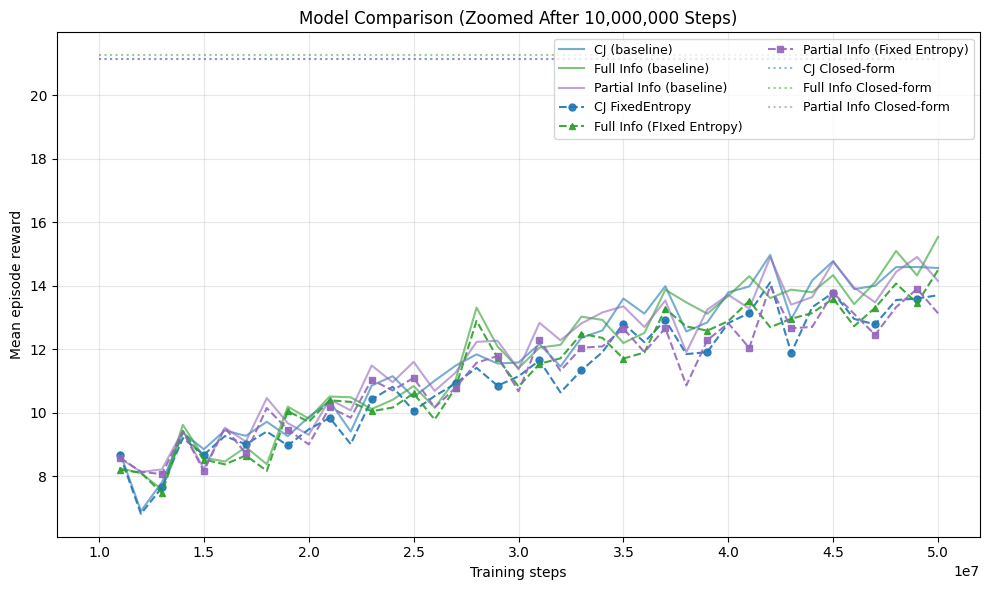

In [37]:
# === Zoomed-in plot after threshold ===

zoom_threshold = 10_000_000

# --- Filter data for steps > threshold ---
def zoom_filter(steps, rewards, threshold):
    return [s for s in steps if s > threshold], [r for s, r in zip(steps, rewards) if s > threshold]

cj_steps_zoom, cj_rewards_zoom = zoom_filter(cj_steps, cj_rewards, zoom_threshold)
full_steps_zoom, full_rewards_zoom = zoom_filter(full_steps, full_rewards, zoom_threshold)
partial_steps_zoom, partial_rewards_zoom = zoom_filter(partial_steps, partial_rewards, zoom_threshold)

cj_Entropy_steps_zoom, cj_Entropy_rewards_zoom = zoom_filter(cj_Entropy_steps, cj_Entropy_rewards, zoom_threshold)
full_Entropy_steps_zoom, full_Entropy_rewards_zoom = zoom_filter(full_Entropy_steps, full_Entropy_rewards, zoom_threshold)
partial_Entropy_steps_zoom, partial_Entropy_rewards_zoom = zoom_filter(partial_Entropy_steps, partial_Entropy_rewards, zoom_threshold)

# === Plot comparison (zoomed) ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps_zoom, cj_rewards_zoom, '-', color='tab:blue', label='CJ (baseline)', alpha=0.6)
ax.plot(full_steps_zoom, full_rewards_zoom, '-', color='tab:green', label='Full Info (baseline)', alpha=0.6)
ax.plot(partial_steps_zoom, partial_rewards_zoom, '-', color='tab:purple', label='Partial Info (baseline)', alpha=0.6)

# ----- OPTUNA RUNS -----
ax.plot(cj_Entropy_steps_zoom, cj_Entropy_rewards_zoom, '--o', color='tab:blue',
        alpha=0.9, markersize=5, markevery=max(1, len(cj_Entropy_steps_zoom)//15),
        label='CJ FixedEntropy')
ax.plot(full_Entropy_steps_zoom, full_Entropy_rewards_zoom, '--^', color='tab:green',
        alpha=0.9, markersize=5, markevery=max(1, len(full_Entropy_steps_zoom)//15),
        label='Full Info (FIxed Entropy)')
ax.plot(partial_Entropy_steps_zoom, partial_Entropy_rewards_zoom, '--s', color='tab:purple',
        alpha=0.9, markersize=5, markevery=max(1, len(partial_Entropy_steps_zoom)//15),
        label='Partial Info (Fixed Entropy)')

# ----- CLOSED-FORM BASELINES -----
x_min = zoom_threshold
x_max = max(cj_steps + full_steps + partial_steps)

y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title(f'Model Comparison (Zoomed After {zoom_threshold:,} Steps)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


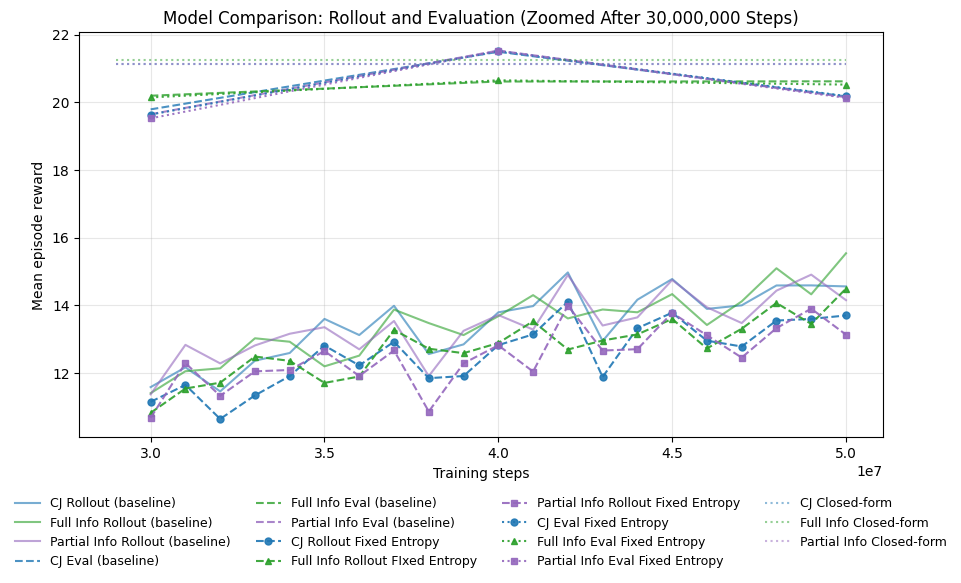

In [38]:
# === Zoomed-in plot after threshold (with evaluation) ===

zoom_threshold = 29_000_000

# --- Helper to filter steps/rewards ---
def zoom_filter(steps, rewards, threshold):
    return [s for s in steps if s > threshold], [r for s, r in zip(steps, rewards) if s > threshold]

# --- Baseline zoomed data ---
cj_steps_zoom, cj_rewards_zoom = zoom_filter(cj_steps, cj_rewards, zoom_threshold)
full_steps_zoom, full_rewards_zoom = zoom_filter(full_steps, full_rewards, zoom_threshold)
partial_steps_zoom, partial_rewards_zoom = zoom_filter(partial_steps, partial_rewards, zoom_threshold)

cj_eval_steps_zoom, cj_eval_rewards_zoom = zoom_filter(cj_eval_steps, cj_eval_rewards, zoom_threshold)
full_eval_steps_zoom, full_eval_rewards_zoom = zoom_filter(full_eval_steps, full_eval_rewards, zoom_threshold)
partial_eval_steps_zoom, partial_eval_rewards_zoom = zoom_filter(partial_eval_steps, partial_eval_rewards, zoom_threshold)

# --- Optuna zoomed data ---
cj_Entropy_steps_zoom, cj_Entropy_rewards_zoom = zoom_filter(cj_Entropy_steps, cj_Entropy_rewards, zoom_threshold)
full_Entropy_steps_zoom, full_Entropy_rewards_zoom = zoom_filter(full_Entropy_steps, full_Entropy_rewards, zoom_threshold)
partial_Entropy_steps_zoom, partial_Entropy_rewards_zoom = zoom_filter(partial_Entropy_steps, partial_Entropy_rewards, zoom_threshold)

cj_Entropy_eval_steps_zoom, cj_Entropy_eval_rewards_zoom = zoom_filter(cj_Entropy_eval_steps, cj_Entropy_eval_rewards, zoom_threshold)
full_Entropy_eval_steps_zoom, full_Entropy_eval_rewards_zoom = zoom_filter(full_Entropy_eval_steps, full_Entropy_eval_rewards, zoom_threshold)
partial_Entropy_eval_steps_zoom, partial_Entropy_eval_rewards_zoom = zoom_filter(partial_Entropy_eval_steps, partial_Entropy_eval_rewards, zoom_threshold)

# === Plot comparison (zoomed) ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps_zoom, cj_rewards_zoom, '-', color='tab:blue', label='CJ Rollout (baseline)', alpha=0.6)
ax.plot(full_steps_zoom, full_rewards_zoom, '-', color='tab:green', label='Full Info Rollout (baseline)', alpha=0.6)
ax.plot(partial_steps_zoom, partial_rewards_zoom, '-', color='tab:purple', label='Partial Info Rollout (baseline)', alpha=0.6)

# Baseline eval
if cj_eval_steps_zoom:
    ax.plot(cj_eval_steps_zoom, cj_eval_rewards_zoom, '--', color='tab:blue', alpha=0.8, label='CJ Eval (baseline)')
if full_eval_steps_zoom:
    ax.plot(full_eval_steps_zoom, full_eval_rewards_zoom, '--', color='tab:green', alpha=0.8, label='Full Info Eval (baseline)')
if partial_eval_steps_zoom:
    ax.plot(partial_eval_steps_zoom, partial_eval_rewards_zoom, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval (baseline)')


ax.plot(cj_Entropy_steps_zoom, cj_Entropy_rewards_zoom, '--o', color='tab:blue', alpha=0.9,
        markersize=5, markevery=max(1, len(cj_Entropy_steps_zoom)//15), label='CJ Rollout Fixed Entropy')
ax.plot(full_Entropy_steps_zoom, full_Entropy_rewards_zoom, '--^', color='tab:green', alpha=0.9,
        markersize=5, markevery=max(1, len(full_Entropy_steps_zoom)//15), label='Full Info Rollout FIxed Entropy')
ax.plot(partial_Entropy_steps_zoom, partial_Entropy_rewards_zoom, '--s', color='tab:purple', alpha=0.9,
        markersize=5, markevery=max(1, len(partial_Entropy_steps_zoom)//15), label='Partial Info Rollout Fixed Entropy')
# Optuna eval (dotted lines with markers)
if cj_Entropy_eval_steps_zoom:
    ax.plot(cj_Entropy_eval_steps_zoom, cj_Entropy_eval_rewards_zoom, ':o', color='tab:blue', alpha=0.9,
            markersize=5, markevery=max(1, len(cj_Entropy_eval_steps_zoom)//15), label='CJ Eval Fixed Entropy')
if full_Entropy_eval_steps_zoom:
    ax.plot(full_Entropy_eval_steps_zoom, full_Entropy_eval_rewards_zoom, ':^', color='tab:green', alpha=0.9,
            markersize=5, markevery=max(1, len(full_Entropy_eval_steps_zoom)//15), label='Full Info Eval Fixed Entropy')
if partial_Entropy_eval_steps_zoom:
    ax.plot(partial_Entropy_eval_steps_zoom, partial_Entropy_eval_rewards_zoom, ':s', color='tab:purple', alpha=0.9,
            markersize=5, markevery=max(1, len(partial_Entropy_eval_steps_zoom)//15), label='Partial Info Eval Fixed Entropy')

# ----- CLOSED-FORM BASELINES -----
x_min = zoom_threshold
x_max = max(cj_steps + full_steps + partial_steps)

y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=x_min, xmax=x_max, linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=x_min, xmax=x_max, linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=x_min, xmax=x_max, linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title(f'Model Comparison: Rollout and Evaluation (Zoomed After 30,000,000 Steps)')
ax.legend(
    ncol=4,
    fontsize=9,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    frameon=False
)
plt.tight_layout()
plt.show()

## Entropy Callback regularization

### Plot for comparison

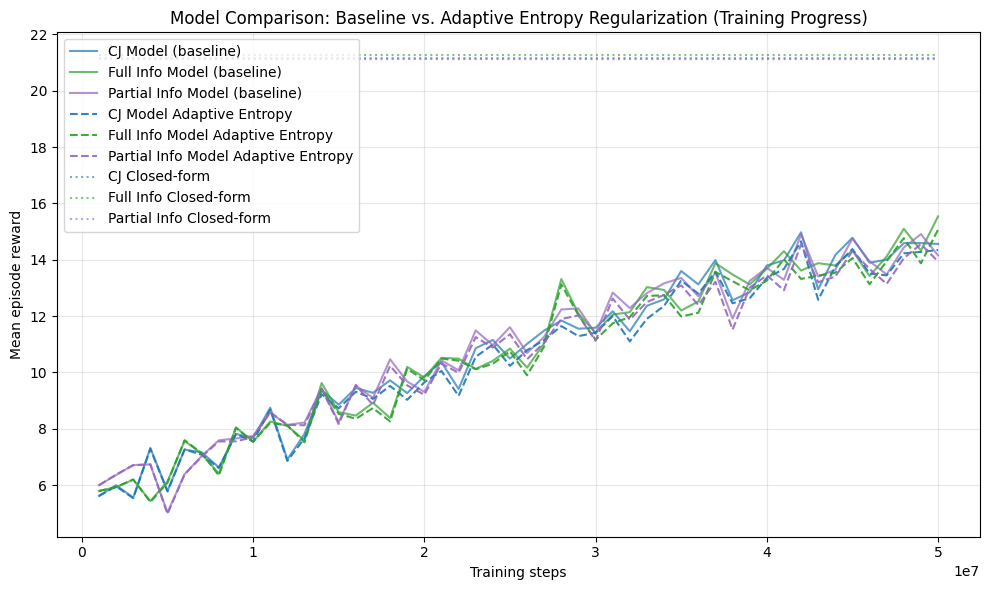

In [39]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# === Load rollout rewards for all six models ===

# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_EntropyCallback_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps_EntropyCallback/2025-11-17_11-22-49/PPO_1/events.out.tfevents.1763374970.MacBookAir.lan.80862.0"
full_info_EntropyCallback_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline_Entropy_Callback/2025-11-17_13-07-44/PPO_1/events.out.tfevents.1763381265.MacBookAir.lan.90498.0"
partial_info_EntropyCallback_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_Entropy_Callback/2025-11-17_11-41-11/PPO_1/events.out.tfevents.1763376072.MacBookAir.lan.83954.0"

# Load the data
# Helper to load rewards
def load_rollout(file_path, tag="rollout/ep_rew_mean"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    rewards = [e.value for e in events]
    return steps, rewards

# Load baseline
cj_steps, cj_rewards = load_rollout(cj_rollout_file)
full_steps, full_rewards = load_rollout(full_info_rollout_file)
partial_steps, partial_rewards = load_rollout(partial_info_rollout_file)

# Load random Inventory
cj_EntropyCallback_steps, cj_EntropyCallback_rewards = load_rollout(cj_EntropyCallback_rollout_file)
full_EntropyCallback_steps, full_EntropyCallback_rewards = load_rollout(full_info_EntropyCallback_rollout_file)
partial_EntropyCallback_steps, partial_EntropyCallback_rewards = load_rollout(partial_info_EntropyCallback_rollout_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# Baseline models
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Model (baseline)', alpha=0.7)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Model (baseline)', alpha=0.7)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Model (baseline)', alpha=0.7)

# Optuna models
ax.plot(cj_EntropyCallback_steps, cj_EntropyCallback_rewards, '--', color='tab:blue', label='CJ Model Adaptive Entropy', alpha=0.9)
ax.plot(full_EntropyCallback_steps, full_EntropyCallback_rewards, '--', color='tab:green', label='Full Info Model Adaptive Entropy', alpha=0.9)
ax.plot(partial_EntropyCallback_steps, partial_EntropyCallback_rewards, '--', color='tab:purple', label='Partial Info Model Adaptive Entropy', alpha=0.9)

# Add closed-form baselines
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.6)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.6)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.6)

# Formatting
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Baseline vs. Adaptive Entropy Regularization (Training Progress)')
ax.legend()
plt.tight_layout()
plt.show()


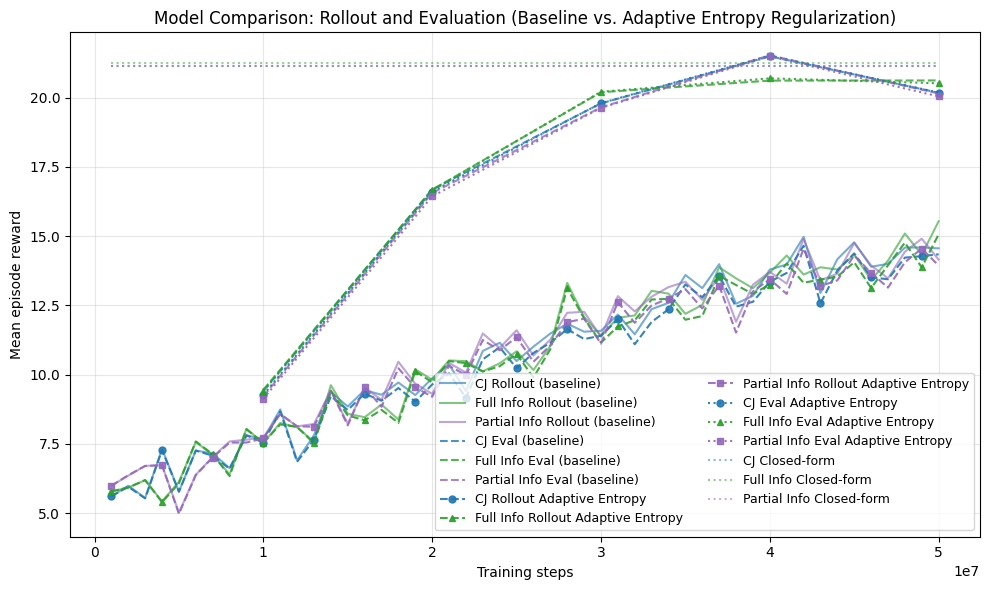

In [40]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

# Define tensorboard files
# Define tensorboard files
cj_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps/2025-11-16_10-09-35/PPO_1/events.out.tfevents.1763284176.MacBookAir.lan.26982.0"
full_info_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline/2025-11-16_18-13-43/PPO_1/events.out.tfevents.1763313225.MacBookAir.lan.37154.0"
partial_info_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_newBaseline/2025-11-16_19-43-31/PPO_1/events.out.tfevents.1763318612.MacBookAir.lan.42104.0"

cj_EntropyCallback_rollout_file = "./CJ_models/tensorboard/PPO-learning/CjMm_New_Baseline_50Msteps_EntropyCallback/2025-11-17_11-22-49/PPO_1/events.out.tfevents.1763374970.MacBookAir.lan.80862.0"
full_info_EntropyCallback_rollout_file = "./Full_Info_models/tensorboard/PPO-learning-FI/FIMm_PPO_50_000_000steps_newBaseline_Entropy_Callback/2025-11-17_13-07-44/PPO_1/events.out.tfevents.1763381265.MacBookAir.lan.90498.0"
partial_info_EntropyCallback_rollout_file = "./Partial_Info_models/tensorboard/PPO-learning/PIMm_PPO_50_000_000steps_Entropy_Callback/2025-11-17_11-41-11/PPO_1/events.out.tfevents.1763376072.MacBookAir.lan.83954.0"

# === Helper to load data ===
def load_rewards(file_path, rollout_tag="rollout/ep_rew_mean", eval_tag="eval/mean_reward"):
    ea = event_accumulator.EventAccumulator(file_path)
    ea.Reload()
    tags = ea.Tags().get('scalars', [])

    rollout_events = ea.Scalars(rollout_tag)
    rollout_steps = [e.step for e in rollout_events]
    rollout_rewards = [e.value for e in rollout_events]

    eval_steps, eval_rewards = [], []
    if eval_tag in tags:
        eval_events = ea.Scalars(eval_tag)
        eval_steps = [e.step for e in eval_events]
        eval_rewards = [e.value for e in eval_events]

    return rollout_steps, rollout_rewards, eval_steps, eval_rewards

# === Load all baseline models ===
cj_steps, cj_rewards, cj_eval_steps, cj_eval_rewards = load_rewards(cj_rollout_file)
full_steps, full_rewards, full_eval_steps, full_eval_rewards = load_rewards(full_info_rollout_file)
partial_steps, partial_rewards, partial_eval_steps, partial_eval_rewards = load_rewards(partial_info_rollout_file)

# === Load all Optuna models ===
cj_EntropyCallback_steps, cj_EntropyCallback_rewards, cj_EntropyCallback_eval_steps, cj_EntropyCallback_eval_rewards = load_rewards(cj_EntropyCallback_rollout_file)
full_EntropyCallback_steps, full_EntropyCallback_rewards, full_EntropyCallback_eval_steps, full_EntropyCallback_eval_rewards = load_rewards(full_info_EntropyCallback_rollout_file)
partial_EntropyCallback_steps, partial_EntropyCallback_rewards, partial_EntropyCallback_eval_steps, partial_EntropyCallback_eval_rewards = load_rewards(partial_info_EntropyCallback_rollout_file)

# === Plot comparison ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps, cj_rewards, '-', color='tab:blue', label='CJ Rollout (baseline)', alpha=0.6)
ax.plot(full_steps, full_rewards, '-', color='tab:green', label='Full Info Rollout (baseline)', alpha=0.6)
ax.plot(partial_steps, partial_rewards, '-', color='tab:purple', label='Partial Info Rollout (baseline)', alpha=0.6)

if cj_eval_steps:
    ax.plot(cj_eval_steps, cj_eval_rewards, '--', color='tab:blue', alpha=0.8, label='CJ Eval (baseline)')
if full_eval_steps:
    ax.plot(full_eval_steps, full_eval_rewards, '--', color='tab:green', alpha=0.8, label='Full Info Eval (baseline)')
if partial_eval_steps:
    ax.plot(partial_eval_steps, partial_eval_rewards, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval (baseline)')


ax.plot(cj_EntropyCallback_steps, cj_EntropyCallback_rewards, '--o', color='tab:blue', alpha=0.9,
        markersize=5, markevery=max(1, len(cj_EntropyCallback_steps)//15), label='CJ Rollout Adaptive Entropy')
ax.plot(full_EntropyCallback_steps, full_EntropyCallback_rewards, '--^', color='tab:green', alpha=0.9,
        markersize=5, markevery=max(1, len(full_EntropyCallback_steps)//15), label='Full Info Rollout Adaptive Entropy')
ax.plot(partial_EntropyCallback_steps, partial_EntropyCallback_rewards, '--s', color='tab:purple', alpha=0.9,
        markersize=5, markevery=max(1, len(partial_EntropyCallback_steps)//15), label='Partial Info Rollout Adaptive Entropy')
# Optuna eval (dotted with markers)
if cj_EntropyCallback_eval_steps:
    ax.plot(cj_EntropyCallback_eval_steps, cj_EntropyCallback_eval_rewards, ':o', color='tab:blue', alpha=0.9,
            markersize=5, markevery=max(1, len(cj_EntropyCallback_eval_steps)//15), label='CJ Eval Adaptive Entropy')
if full_EntropyCallback_eval_steps:
    ax.plot(full_EntropyCallback_eval_steps, full_EntropyCallback_eval_rewards, ':^', color='tab:green', alpha=0.9,
            markersize=5, markevery=max(1, len(full_EntropyCallback_eval_steps)//15), label='Full Info Eval Adaptive Entropy')
if partial_EntropyCallback_eval_steps:
    ax.plot(partial_EntropyCallback_eval_steps, partial_EntropyCallback_eval_rewards, ':s', color='tab:purple', alpha=0.9,
            markersize=5, markevery=max(1, len(partial_EntropyCallback_eval_steps)//15), label='Partial Info Eval Adaptive Entropy')

# ----- CLOSED-FORM BASELINES -----
all_steps = cj_steps + full_steps + partial_steps
y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=min(all_steps), xmax=max(all_steps),
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title('Model Comparison: Rollout and Evaluation (Baseline vs. Adaptive Entropy Regularization)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()



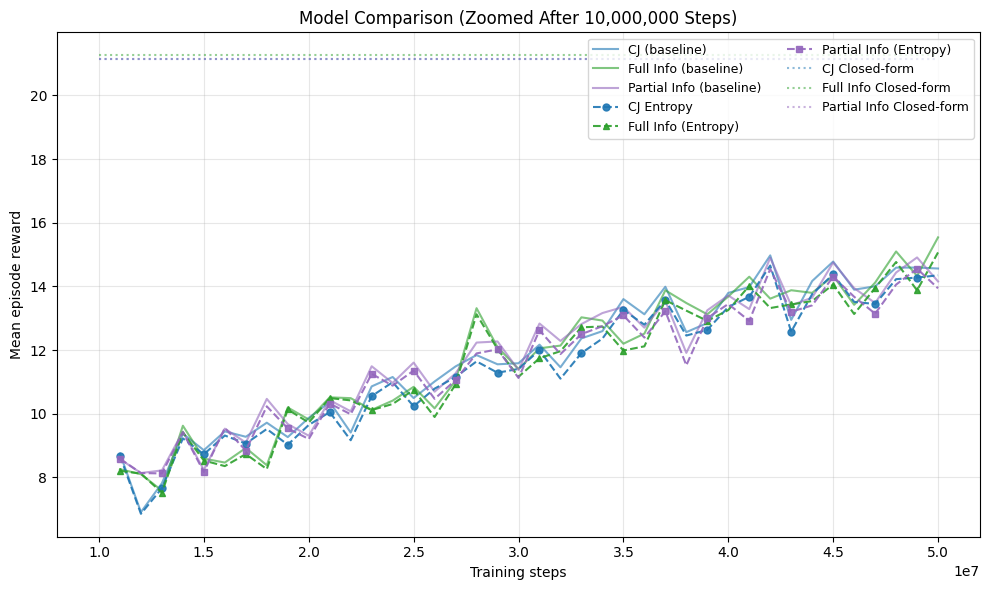

In [41]:
# === Zoomed-in plot after threshold ===

zoom_threshold = 10_000_000

# --- Filter data for steps > threshold ---
def zoom_filter(steps, rewards, threshold):
    return [s for s in steps if s > threshold], [r for s, r in zip(steps, rewards) if s > threshold]

cj_steps_zoom, cj_rewards_zoom = zoom_filter(cj_steps, cj_rewards, zoom_threshold)
full_steps_zoom, full_rewards_zoom = zoom_filter(full_steps, full_rewards, zoom_threshold)
partial_steps_zoom, partial_rewards_zoom = zoom_filter(partial_steps, partial_rewards, zoom_threshold)

cj_EntropyCallback_steps_zoom, cj_EntropyCallback_rewards_zoom = zoom_filter(cj_EntropyCallback_steps, cj_EntropyCallback_rewards, zoom_threshold)
full_EntropyCallback_steps_zoom, full_EntropyCallback_rewards_zoom = zoom_filter(full_EntropyCallback_steps, full_EntropyCallback_rewards, zoom_threshold)
partial_EntropyCallback_steps_zoom, partial_EntropyCallback_rewards_zoom = zoom_filter(partial_EntropyCallback_steps, partial_EntropyCallback_rewards, zoom_threshold)

# === Plot comparison (zoomed) ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps_zoom, cj_rewards_zoom, '-', color='tab:blue', label='CJ (baseline)', alpha=0.6)
ax.plot(full_steps_zoom, full_rewards_zoom, '-', color='tab:green', label='Full Info (baseline)', alpha=0.6)
ax.plot(partial_steps_zoom, partial_rewards_zoom, '-', color='tab:purple', label='Partial Info (baseline)', alpha=0.6)

# ----- OPTUNA RUNS -----
ax.plot(cj_EntropyCallback_steps_zoom, cj_EntropyCallback_rewards_zoom, '--o', color='tab:blue',
        alpha=0.9, markersize=5, markevery=max(1, len(cj_EntropyCallback_steps_zoom)//15),
        label='CJ Entropy')
ax.plot(full_EntropyCallback_steps_zoom, full_EntropyCallback_rewards_zoom, '--^', color='tab:green',
        alpha=0.9, markersize=5, markevery=max(1, len(full_EntropyCallback_steps_zoom)//15),
        label='Full Info (Entropy)')
ax.plot(partial_EntropyCallback_steps_zoom, partial_EntropyCallback_rewards_zoom, '--s', color='tab:purple',
        alpha=0.9, markersize=5, markevery=max(1, len(partial_EntropyCallback_steps_zoom)//15),
        label='Partial Info (Entropy)')

# ----- CLOSED-FORM BASELINES -----
x_min = zoom_threshold
x_max = max(cj_steps + full_steps + partial_steps)

y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=x_min, xmax=x_max,
          linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title(f'Model Comparison (Zoomed After {zoom_threshold:,} Steps)')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


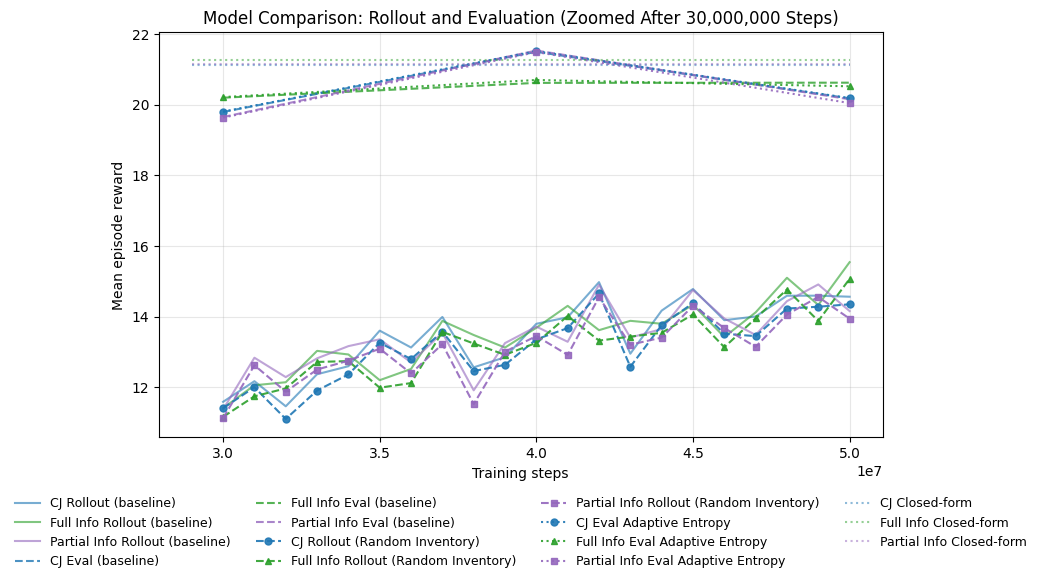

In [42]:
# === Zoomed-in plot after threshold (with evaluation) ===

zoom_threshold = 29_000_000

# --- Helper to filter steps/rewards ---
def zoom_filter(steps, rewards, threshold):
    return [s for s in steps if s > threshold], [r for s, r in zip(steps, rewards) if s > threshold]

# --- Baseline zoomed data ---
cj_steps_zoom, cj_rewards_zoom = zoom_filter(cj_steps, cj_rewards, zoom_threshold)
full_steps_zoom, full_rewards_zoom = zoom_filter(full_steps, full_rewards, zoom_threshold)
partial_steps_zoom, partial_rewards_zoom = zoom_filter(partial_steps, partial_rewards, zoom_threshold)

cj_eval_steps_zoom, cj_eval_rewards_zoom = zoom_filter(cj_eval_steps, cj_eval_rewards, zoom_threshold)
full_eval_steps_zoom, full_eval_rewards_zoom = zoom_filter(full_eval_steps, full_eval_rewards, zoom_threshold)
partial_eval_steps_zoom, partial_eval_rewards_zoom = zoom_filter(partial_eval_steps, partial_eval_rewards, zoom_threshold)

# --- Optuna zoomed data ---
cj_EntropyCallback_steps_zoom, cj_EntropyCallback_rewards_zoom = zoom_filter(cj_EntropyCallback_steps, cj_EntropyCallback_rewards, zoom_threshold)
full_EntropyCallback_steps_zoom, full_EntropyCallback_rewards_zoom = zoom_filter(full_EntropyCallback_steps, full_EntropyCallback_rewards, zoom_threshold)
partial_EntropyCallback_steps_zoom, partial_EntropyCallback_rewards_zoom = zoom_filter(partial_EntropyCallback_steps, partial_EntropyCallback_rewards, zoom_threshold)

cj_EntropyCallback_eval_steps_zoom, cj_EntropyCallback_eval_rewards_zoom = zoom_filter(cj_EntropyCallback_eval_steps, cj_EntropyCallback_eval_rewards, zoom_threshold)
full_EntropyCallback_eval_steps_zoom, full_EntropyCallback_eval_rewards_zoom = zoom_filter(full_EntropyCallback_eval_steps, full_EntropyCallback_eval_rewards, zoom_threshold)
partial_EntropyCallback_eval_steps_zoom, partial_EntropyCallback_eval_rewards_zoom = zoom_filter(partial_EntropyCallback_eval_steps, partial_EntropyCallback_eval_rewards, zoom_threshold)

# === Plot comparison (zoomed) ===
fig, ax = plt.subplots(figsize=(10, 6))

# ----- BASELINE RUNS -----
ax.plot(cj_steps_zoom, cj_rewards_zoom, '-', color='tab:blue', label='CJ Rollout (baseline)', alpha=0.6)
ax.plot(full_steps_zoom, full_rewards_zoom, '-', color='tab:green', label='Full Info Rollout (baseline)', alpha=0.6)
ax.plot(partial_steps_zoom, partial_rewards_zoom, '-', color='tab:purple', label='Partial Info Rollout (baseline)', alpha=0.6)

# Baseline eval
if cj_eval_steps_zoom:
    ax.plot(cj_eval_steps_zoom, cj_eval_rewards_zoom, '--', color='tab:blue', alpha=0.8, label='CJ Eval (baseline)')
if full_eval_steps_zoom:
    ax.plot(full_eval_steps_zoom, full_eval_rewards_zoom, '--', color='tab:green', alpha=0.8, label='Full Info Eval (baseline)')
if partial_eval_steps_zoom:
    ax.plot(partial_eval_steps_zoom, partial_eval_rewards_zoom, '--', color='tab:purple', alpha=0.8, label='Partial Info Eval (baseline)')


ax.plot(cj_EntropyCallback_steps_zoom, cj_EntropyCallback_rewards_zoom, '--o', color='tab:blue', alpha=0.9,
        markersize=5, markevery=max(1, len(cj_EntropyCallback_steps_zoom)//15), label='CJ Rollout (Random Inventory)')
ax.plot(full_EntropyCallback_steps_zoom, full_EntropyCallback_rewards_zoom, '--^', color='tab:green', alpha=0.9,
        markersize=5, markevery=max(1, len(full_EntropyCallback_steps_zoom)//15), label='Full Info Rollout (Random Inventory)')
ax.plot(partial_EntropyCallback_steps_zoom, partial_EntropyCallback_rewards_zoom, '--s', color='tab:purple', alpha=0.9,
        markersize=5, markevery=max(1, len(partial_EntropyCallback_steps_zoom)//15), label='Partial Info Rollout (Random Inventory)')
# Optuna eval (dotted lines with markers)
if cj_EntropyCallback_eval_steps_zoom:
    ax.plot(cj_EntropyCallback_eval_steps_zoom, cj_EntropyCallback_eval_rewards_zoom, ':o', color='tab:blue', alpha=0.9,
            markersize=5, markevery=max(1, len(cj_EntropyCallback_eval_steps_zoom)//15), label='CJ Eval Adaptive Entropy')
if full_EntropyCallback_eval_steps_zoom:
    ax.plot(full_EntropyCallback_eval_steps_zoom, full_EntropyCallback_eval_rewards_zoom, ':^', color='tab:green', alpha=0.9,
            markersize=5, markevery=max(1, len(full_EntropyCallback_eval_steps_zoom)//15), label='Full Info Eval Adaptive Entropy')
if partial_EntropyCallback_eval_steps_zoom:
    ax.plot(partial_EntropyCallback_eval_steps_zoom, partial_EntropyCallback_eval_rewards_zoom, ':s', color='tab:purple', alpha=0.9,
            markersize=5, markevery=max(1, len(partial_EntropyCallback_eval_steps_zoom)//15), label='Partial Info Eval Adaptive Entropy')

# ----- CLOSED-FORM BASELINES -----
x_min = zoom_threshold
x_max = max(cj_steps + full_steps + partial_steps)

y_line_cj = float(results_cj["Mean PnL"].iloc[0])
y_line_full = float(results_fi["Mean PnL"].iloc[0])
y_line_partial = float(results_pi["Mean PnL"].iloc[0])

ax.hlines(y=y_line_cj, xmin=x_min, xmax=x_max, linestyles=':', color='tab:blue', label='CJ Closed-form', alpha=0.5)
ax.hlines(y=y_line_full, xmin=x_min, xmax=x_max, linestyles=':', color='tab:green', label='Full Info Closed-form', alpha=0.5)
ax.hlines(y=y_line_partial, xmin=x_min, xmax=x_max, linestyles=':', color='tab:purple', label='Partial Info Closed-form', alpha=0.5)

# ----- FORMATTING -----
ax.grid(alpha=0.3)
ax.set_xlabel('Training steps')
ax.set_ylabel('Mean episode reward')
ax.set_title(f'Model Comparison: Rollout and Evaluation (Zoomed After 30,000,000 Steps)')
ax.legend(
    ncol=4,
    fontsize=9,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    frameon=False
)
plt.tight_layout()
plt.show()